# Cloud Masking Sentinel-2 Imagery

This notebook shows how to download a Sentinel-2 scene using `s2dl` and generate a cloud mask with OmniCloudMask.

> **Note:** OmniCloudMask supports both Sentinel-2 **L1C** (top-of-atmosphere) and **L2A** (surface reflectance) processing levels.

In [1]:
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from omnicloudmask import load_s2, predict_from_load_func
from s2dl import fetch_single_sentinel_product

## 1. Download a Sentinel-2 scene

Set up a local directory to store the downloaded scene, then fetch it using the Sentinel-2 product ID.

In [2]:
test_data_dir = Path.cwd() / "Sentinel-2 data"
test_data_dir.mkdir(exist_ok=True, parents=True)

Download the scene if it is not already present locally. The `fetch_single_sentinel_product` function retrieves the `.SAFE` archive from the Copernicus Data Space.

In [3]:
product_id = "S2A_MSIL1C_20230304T020441_N0509_R017_T50HNH_20230304T051523"
scene_dir = test_data_dir / (product_id + ".SAFE")
if not scene_dir.exists():
    fetch_single_sentinel_product(
        product_id,
        test_data_dir,
    )
scene_dir

PosixPath('/Users/nick/Documents/Work Code/OmniCloudMask/examples/Sentinel-2 data/S2A_MSIL1C_20230304T020441_N0509_R017_T50HNH_20230304T051523.SAFE')

## 2. Run OmniCloudMask

Use `predict_from_load_func` with the built-in `load_s2` loader. Processing at 20 m halves the pixel count compared to 10 m and gives much faster inference with negligible impact on mask quality.

In [4]:
load_s2_20m = partial(load_s2, resolution=20.0)

If no `output_dir` is specified the mask is saved alongside the `.SAFE` directory. Pass a list of scene paths even for a single scene.

In [5]:
pred_paths = predict_from_load_func(
    scene_paths=[scene_dir],
    load_func=load_s2_20m,
)

Running inference using mps float32:   0%|          | 0/1 [00:00<?, ?it/s]

## 3. Visualise

Load the Blue band in addition to the Red, Green bands already used for inference to build a true-colour composite. Apply a power-0.5 stretch followed by min-max normalisation for display.

In [6]:
# Load RGB bands for display (power stretch + min-max normalisation)
scene_RGB, _ = load_s2_20m(scene_dir, required_bands=["B04", "B03", "B02"])
arr = np.power(scene_RGB.astype(np.float32), 0.5)
arr -= arr.min()
arr /= arr.max()
rgb_display = np.clip(arr, 0, 1).transpose(1, 2, 0)

# Load the saved mask
with rasterio.open(pred_paths[0]) as src:
    mask = src.read()

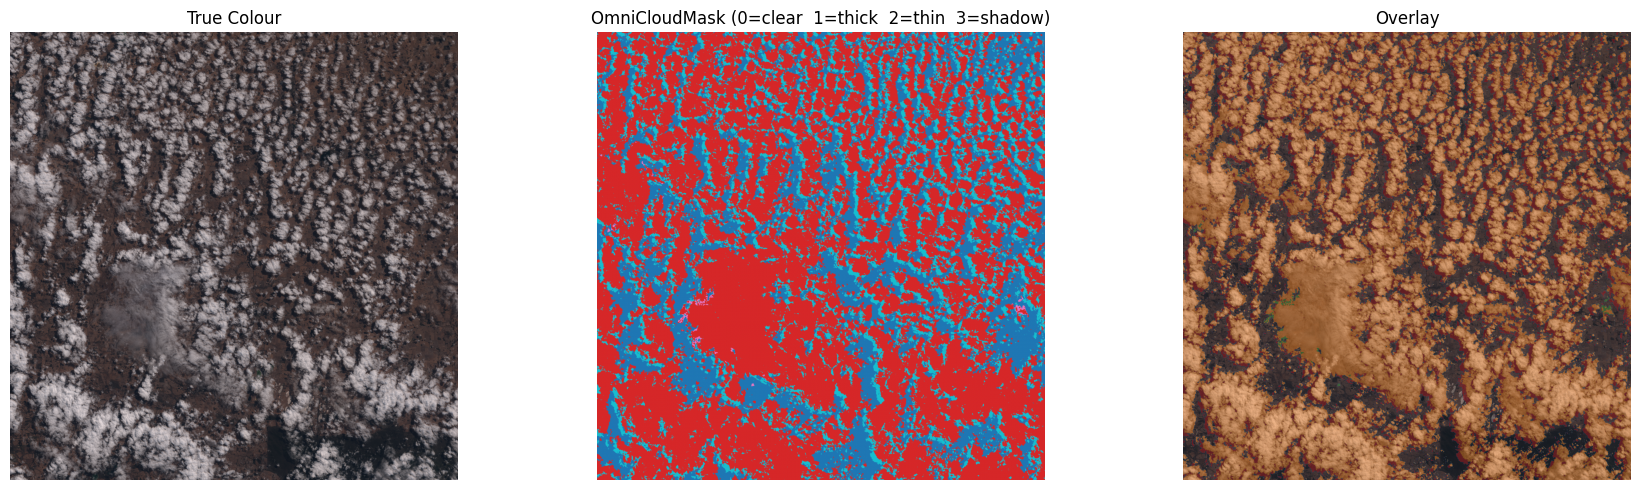

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: true colour
axes[0].imshow(rgb_display)
axes[0].set_title("True Colour")
axes[0].axis("off")

# Panel 2: cloud mask
axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

# Panel 3: overlay — clear pixels transparent, others at 40% opacity
tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb_display)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

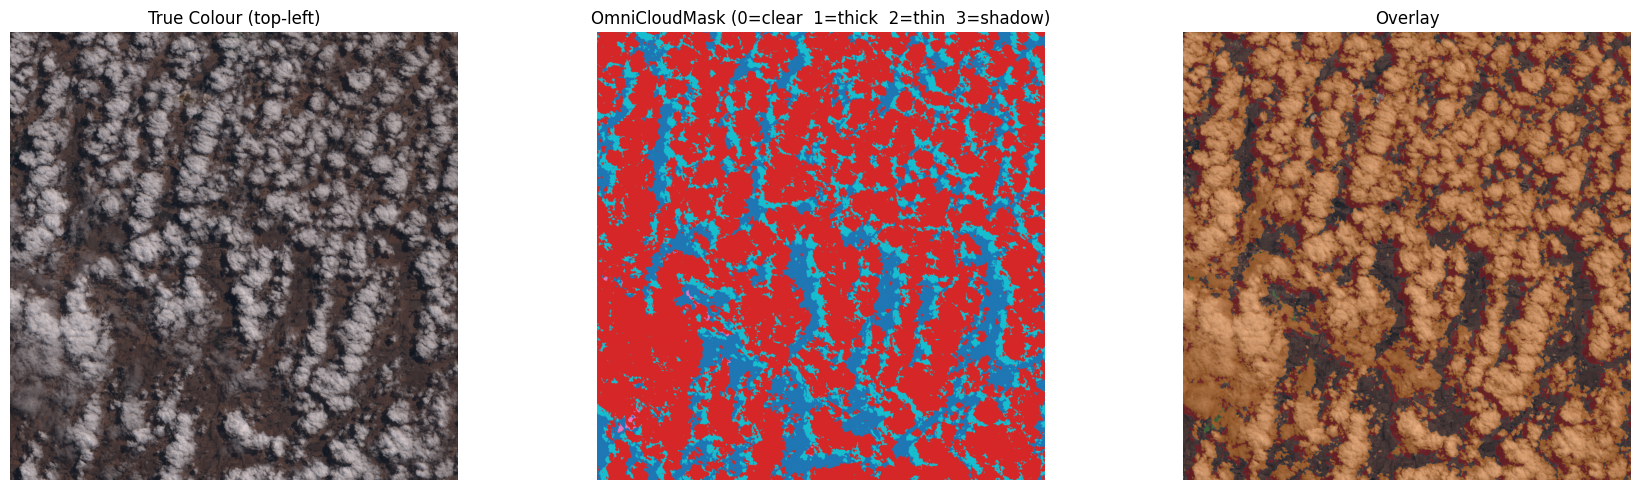

In [8]:
h, w = mask_sq.shape
rs, re, cs, ce = 0, h // 2, 0, w // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(rgb_display[rs:re, cs:ce])
axes[0].set_title("True Colour (top-left)")
axes[0].axis("off")
axes[1].imshow(mask_sq[rs:re, cs:ce], cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")
axes[2].imshow(rgb_display[rs:re, cs:ce])
axes[2].imshow(rgba[rs:re, cs:ce])
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()